# HW10-11

In [23]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.datasets import CIFAR100, OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights
from torchvision.utils import draw_bounding_boxes

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [2]:
BASE_DIR = Path('./homeworks/HW10-11')
ART_DIR = BASE_DIR / 'artifacts'
FIG_DIR = ART_DIR / 'figures'
ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR:', BASE_DIR.resolve())
print('ART_DIR:', ART_DIR.resolve())
print('FIG_DIR:', FIG_DIR.resolve())

BASE_DIR: C:\Users\frase\3 курс\дпо\homeworks\HW10-11
ART_DIR: C:\Users\frase\3 курс\дпо\homeworks\HW10-11\artifacts
FIG_DIR: C:\Users\frase\3 курс\дпо\homeworks\HW10-11\artifacts\figures


## 1. Часть A — CIFAR100: данные, transforms, sanity-check

Files already downloaded and verified
Files already downloaded and verified
x_batch.shape: torch.Size([8, 3, 32, 32])
y_batch.shape: torch.Size([8])
Classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflo

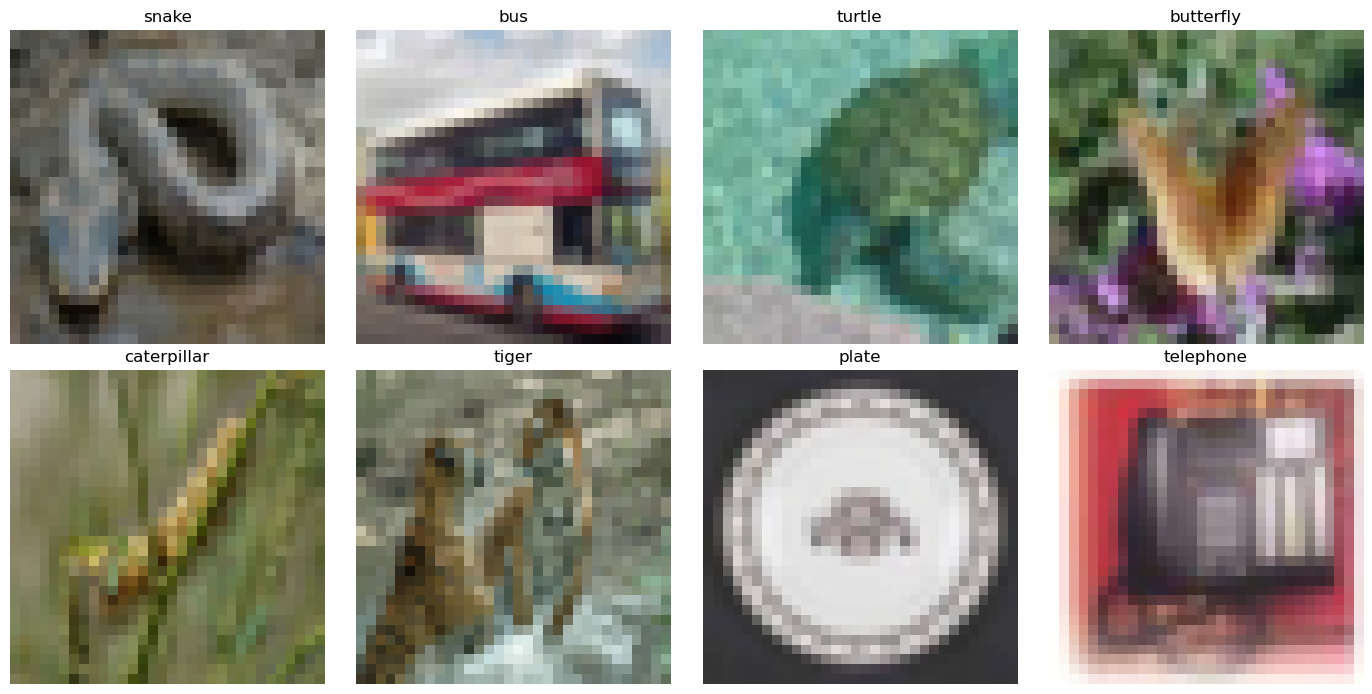

Saved: homeworks\HW10-11\artifacts\figures\augmentations_preview.png


In [3]:
DATA_ROOT = './data'
NUM_CLASSES = 100
IMAGE_SIZE = 32
BATCH_SIZE_CNN = 64
BATCH_SIZE_RESNET = 32
VAL_FRAC = 0.2
SUBSET_SIZE = 20000

cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

cnn_base_train_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(cifar100_mean, cifar100_std),
])

cnn_aug_train_tf = T.Compose([
    T.RandomCrop(IMAGE_SIZE, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(cifar100_mean, cifar100_std),
])

cnn_eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(cifar100_mean, cifar100_std),
])

resnet_weights = ResNet18_Weights.DEFAULT
resnet_train_tf = resnet_weights.transforms()
resnet_eval_tf = resnet_weights.transforms()

preview_aug_tf = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
])

class IndexedDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]

def make_split_indices(n, val_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    val_size = int(n * val_frac)
    return indices[val_size:], indices[:val_size]

def build_cifar100_datasets(train_tf, eval_tf, seed=42, subset_size=None):
    base_train = CIFAR100(root=DATA_ROOT, train=True, download=True, transform=None)
    train_idx, val_idx = make_split_indices(len(base_train), val_frac=VAL_FRAC, seed=seed)
    
    if subset_size is not None:
        train_idx = train_idx[:subset_size]
        
    train_ds = IndexedDataset(CIFAR100(root=DATA_ROOT, train=True, download=False, transform=train_tf), train_idx)
    val_ds = IndexedDataset(CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tf), val_idx)
    test_ds = CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tf)
    return train_ds, val_ds, test_ds

def get_loader(ds, batch_size, shuffle=False, num_workers=0):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

train_ds_cnn_base, val_ds_cnn_base, test_ds_cnn_base = build_cifar100_datasets(cnn_base_train_tf, cnn_eval_tf, seed=SEED)
train_loader_preview = get_loader(train_ds_cnn_base, batch_size=8, shuffle=True)
x_batch, y_batch = next(iter(train_loader_preview))
print('x_batch.shape:', x_batch.shape)
print('y_batch.shape:', y_batch.shape)

classes_cifar100 = CIFAR100(root=DATA_ROOT, train=True, download=False).classes
print('Classes:', classes_cifar100)

def denormalize_cifar100(x):
    mean = torch.tensor(cifar100_mean).view(3, 1, 1)
    std = torch.tensor(cifar100_std).view(3, 1, 1)
    return torch.clamp(x * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, label in zip(axes.flatten(), x_batch, y_batch):
    img_show = denormalize_cifar100(img).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(classes_cifar100[int(label)])
    ax.axis('off')
plt.tight_layout()
preview_path = FIG_DIR / 'augmentations_preview.png'
plt.savefig(preview_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', preview_path)

## 2. Часть A — модели, обучение и сравнение

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def train_one_epoch(model, loader, optimizer, criterion, device, desc='Train'):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in pbar:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += batch_size
        pbar.set_postfix(loss=f'{total_loss / total_count:.4f}', acc=f'{total_correct / total_count:.4f}')
    return total_loss / total_count, total_correct / total_count

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc='Val'):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in pbar:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += batch_size
        pbar.set_postfix(loss=f'{total_loss / total_count:.4f}', acc=f'{total_correct / total_count:.4f}')
    return total_loss / total_count, total_correct / total_count

def fit_classifier(experiment_id, model, train_loader, val_loader, epochs, lr, optimizer_name='Adam', weight_decay=0.0, notes=''):
    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    model = model.to(device)
    best_state = None
    best_val_acc = -1.0
    best_epoch = -1
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    epoch_bar = tqdm(range(1, epochs + 1), desc=f'[{experiment_id}] epochs')
    for epoch in epoch_bar:
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, desc=f'[{experiment_id}] train {epoch}/{epochs}')
        val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc=f'[{experiment_id}] val   {epoch}/{epochs}')
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', train_acc=f'{train_acc:.4f}', val_loss=f'{val_loss:.4f}', val_acc=f'{val_acc:.4f}', best=f'{best_val_acc:.4f}')
        print(f'[{experiment_id}] epoch {epoch:02d}/{epochs} train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    result = {
        'experiment_id': experiment_id,
        'task': 'classification',
        'dataset': 'CIFAR100',
        'seed': SEED,
        'model_summary': model.__class__.__name__,
        'optimizer': optimizer_name,
        'lr': lr,
        'epochs_trained': epochs,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': notes,
        'best_epoch': best_epoch,
    }
    return model, best_state, history, result

def make_resnet18(num_classes=100, finetune=False):
    model = resnet18(weights=resnet_weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    if not finetune:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    return model

def plot_history(history, title, save_path):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='val')
    axes[0].set_title(f'{title} — loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()
    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['val_acc'], label='val')
    axes[1].set_title(f'{title} — accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)

In [5]:
experiments = []

In [6]:
train_ds_c1, val_ds_c1, test_ds_c1 = build_cifar100_datasets(cnn_base_train_tf, cnn_eval_tf, seed=SEED, subset_size=SUBSET_SIZE)
train_loader_c1 = get_loader(train_ds_c1, BATCH_SIZE_CNN, shuffle=True)
val_loader_c1 = get_loader(val_ds_c1, BATCH_SIZE_CNN, shuffle=False)
test_loader_c1 = get_loader(test_ds_c1, BATCH_SIZE_CNN, shuffle=False)
model_c1 = SimpleCNN(NUM_CLASSES)
model_c1, state_c1, hist_c1, res_c1 = fit_classifier('C1', model_c1, train_loader_c1, val_loader_c1, epochs=5, lr=1e-3, optimizer_name='Adam', notes='simple CNN without augmentations')
experiments.append((res_c1, hist_c1))

Files already downloaded and verified
Files already downloaded and verified


[C1] epochs:   0%|          | 0/5 [00:00<?, ?it/s]

[C1] train 1/5:   0%|          | 0/313 [00:00<?, ?it/s]

[C1] val   1/5:   0%|          | 0/157 [00:00<?, ?it/s]

[C1] epoch 01/5 train_loss=3.9827 train_acc=0.0930 val_loss=3.5861 val_acc=0.1501


...

[C1] val   4/5:   0%|          | 0/157 [00:00<?, ?it/s]

[C1] epoch 04/5 train_loss=2.9985 train_acc=0.2560 val_loss=3.0282 val_acc=0.2511


[C1] train 5/5:   0%|          | 0/313 [00:00<?, ?it/s]

[C1] val   5/5:   0%|          | 0/157 [00:00<?, ?it/s]

[C1] epoch 05/5 train_loss=2.8557 train_acc=0.2853 val_loss=2.9493 val_acc=0.2600


In [7]:
train_ds_c2, val_ds_c2, test_ds_c2 = build_cifar100_datasets(cnn_aug_train_tf, cnn_eval_tf, seed=SEED, subset_size=SUBSET_SIZE)
train_loader_c2 = get_loader(train_ds_c2, BATCH_SIZE_CNN, shuffle=True)
val_loader_c2 = get_loader(val_ds_c2, BATCH_SIZE_CNN, shuffle=False)
test_loader_c2 = get_loader(test_ds_c2, BATCH_SIZE_CNN, shuffle=False)
model_c2 = SimpleCNN(NUM_CLASSES)
model_c2, state_c2, hist_c2, res_c2 = fit_classifier('C2', model_c2, train_loader_c2, val_loader_c2, epochs=5, lr=1e-3, optimizer_name='Adam', notes='same CNN with augmentations')
experiments.append((res_c2, hist_c2))

Files already downloaded and verified
Files already downloaded and verified


[C2] epochs:   0%|          | 0/5 [00:00<?, ?it/s]

[C2] train 1/5:   0%|          | 0/313 [00:00<?, ?it/s]

[C2] val   1/5:   0%|          | 0/157 [00:00<?, ?it/s]

[C2] epoch 01/5 train_loss=4.0891 train_acc=0.0751 val_loss=3.8305 val_acc=0.1088


...

[C2] val   4/5:   0%|          | 0/157 [00:00<?, ?it/s]

[C2] epoch 04/5 train_loss=3.2486 train_acc=0.2089 val_loss=3.2309 val_acc=0.2045


[C2] train 5/5:   0%|          | 0/313 [00:00<?, ?it/s]

[C2] val   5/5:   0%|          | 0/157 [00:00<?, ?it/s]

[C2] epoch 05/5 train_loss=3.1384 train_acc=0.2316 val_loss=3.0615 val_acc=0.2489


In [8]:
train_ds_c3, val_ds_c3, test_ds_c3 = build_cifar100_datasets(resnet_train_tf, resnet_eval_tf, seed=SEED, subset_size=SUBSET_SIZE)
train_loader_c3 = get_loader(train_ds_c3, BATCH_SIZE_RESNET, shuffle=True)
val_loader_c3 = get_loader(val_ds_c3, BATCH_SIZE_RESNET, shuffle=False)
test_loader_c3 = get_loader(test_ds_c3, BATCH_SIZE_RESNET, shuffle=False)
model_c3 = make_resnet18(NUM_CLASSES, finetune=False)
model_c3, state_c3, hist_c3, res_c3 = fit_classifier('C3', model_c3, train_loader_c3, val_loader_c3, epochs=3, lr=1e-3, optimizer_name='Adam', notes='ResNet18 pretrained, frozen backbone, train head only')
experiments.append((res_c3, hist_c3))

Files already downloaded and verified
Files already downloaded and verified


[C3] epochs:   0%|          | 0/3 [00:00<?, ?it/s]

[C3] train 1/3:   0%|          | 0/625 [00:00<?, ?it/s]

[C3] val   1/3:   0%|          | 0/313 [00:00<?, ?it/s]

[C3] epoch 01/3 train_loss=2.9909 train_acc=0.3070 val_loss=2.1807 val_acc=0.4493


...

[C3] val   2/3:   0%|          | 0/313 [00:00<?, ?it/s]

[C3] epoch 02/3 train_loss=1.9977 train_acc=0.4840 val_loss=1.9016 val_acc=0.4953


[C3] train 3/3:   0%|          | 0/625 [00:00<?, ?it/s]

[C3] val   3/3:   0%|          | 0/313 [00:00<?, ?it/s]

[C3] epoch 03/3 train_loss=1.7621 train_acc=0.5300 val_loss=1.8290 val_acc=0.5083


In [9]:
train_ds_c4, val_ds_c4, test_ds_c4 = build_cifar100_datasets(resnet_train_tf, resnet_eval_tf, seed=SEED, subset_size=SUBSET_SIZE)
train_loader_c4 = get_loader(train_ds_c4, BATCH_SIZE_RESNET, shuffle=True)
val_loader_c4 = get_loader(val_ds_c4, BATCH_SIZE_RESNET, shuffle=False)
test_loader_c4 = get_loader(test_ds_c4, BATCH_SIZE_RESNET, shuffle=False)
model_c4 = make_resnet18(NUM_CLASSES, finetune=True)
model_c4, state_c4, hist_c4, res_c4 = fit_classifier('C4', model_c4, train_loader_c4, val_loader_c4, epochs=3, lr=1e-4, optimizer_name='Adam', notes='ResNet18 pretrained, layer4 + fc trainable')
experiments.append((res_c4, hist_c4))

Files already downloaded and verified
Files already downloaded and verified


[C4] epochs:   0%|          | 0/3 [00:00<?, ?it/s]

[C4] train 1/3:   0%|          | 0/625 [00:00<?, ?it/s]

[C4] val   1/3:   0%|          | 0/313 [00:00<?, ?it/s]

[C4] epoch 01/3 train_loss=2.6128 train_acc=0.4030 val_loss=1.6764 val_acc=0.5693


...

[C4] val   2/3:   0%|          | 0/313 [00:00<?, ?it/s]

[C4] epoch 02/3 train_loss=1.3263 train_acc=0.6771 val_loss=1.3446 val_acc=0.6352


[C4] train 3/3:   0%|          | 0/625 [00:00<?, ?it/s]

[C4] val   3/3:   0%|          | 0/313 [00:00<?, ?it/s]

[C4] epoch 03/3 train_loss=0.7702 train_acc=0.8262 val_loss=1.2494 val_acc=0.6537


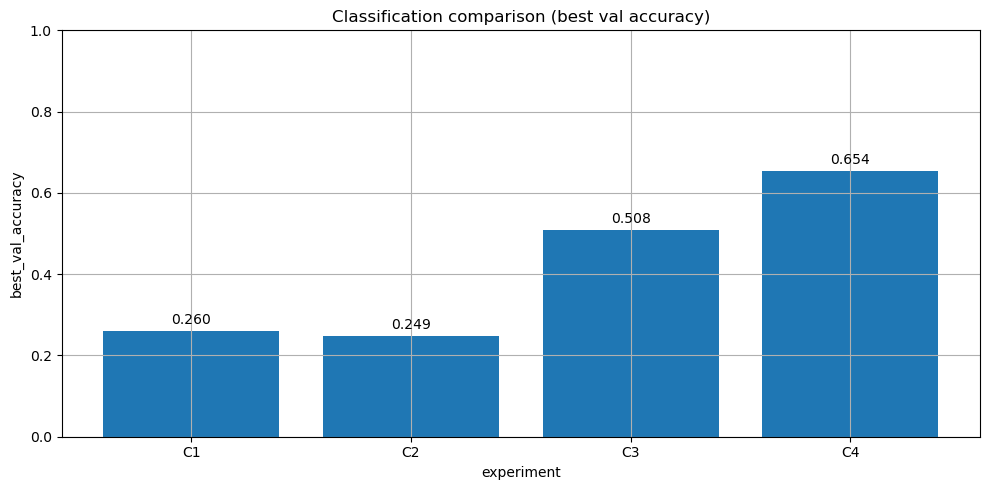

Saved: homeworks\HW10-11\artifacts\figures\classification_compare.png


{'experiment_id': 'C4',
 'task': 'classification',
 'dataset': 'CIFAR100',
 'seed': 42,
 'model_summary': 'ResNet',
 'optimizer': 'Adam',
 'lr': 0.0001,
 'epochs_trained': 3,
 'best_val_accuracy': 0.6537,
 'test_accuracy': None,
 'precision': None,
 'recall': None,
 'mean_iou': None,
 'notes': 'ResNet18 pretrained, layer4 + fc trainable',
 'best_epoch': 3}

In [10]:
results = [r for r, _ in experiments]
compare_ids = [r['experiment_id'] for r in results]
compare_vals = [r['best_val_accuracy'] for r in results]
plt.figure(figsize=(10, 5))
bars = plt.bar(compare_ids, compare_vals)
plt.title('Classification comparison (best val accuracy)')
plt.xlabel('experiment')
plt.ylabel('best_val_accuracy')
plt.ylim(0, 1)
for bar, val in zip(bars, compare_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.3f}', ha='center', va='bottom')
compare_path = FIG_DIR / 'classification_compare.png'
plt.tight_layout()
plt.savefig(compare_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', compare_path)

best_result = max(results, key=lambda x: x['best_val_accuracy'])
best_experiment_id = best_result['experiment_id']
best_result

In [11]:
if best_experiment_id == 'C1':
    best_model = SimpleCNN(NUM_CLASSES)
    best_model.load_state_dict(state_c1)
    best_state = state_c1
    best_history = hist_c1
    best_loader = test_loader_c1
    best_config = {
        'experiment_id': 'C1',
        'dataset': 'CIFAR100',
        'architecture': 'SimpleCNN',
        'train_transform': 'cnn_base_train_tf',
        'eval_transform': 'cnn_eval_tf',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': 5,
        'seed': SEED,
    }
elif best_experiment_id == 'C2':
    best_model = SimpleCNN(NUM_CLASSES)
    best_model.load_state_dict(state_c2)
    best_state = state_c2
    best_history = hist_c2
    best_loader = test_loader_c2
    best_config = {
        'experiment_id': 'C2',
        'dataset': 'CIFAR100',
        'architecture': 'SimpleCNN',
        'train_transform': 'cnn_aug_train_tf',
        'eval_transform': 'cnn_eval_tf',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': 5,
        'seed': SEED,
    }
elif best_experiment_id == 'C3':
    best_model = make_resnet18(NUM_CLASSES, finetune=False)
    best_model.load_state_dict(state_c3)
    best_state = state_c3
    best_history = hist_c3
    best_loader = test_loader_c3
    best_config = {
        'experiment_id': 'C3',
        'dataset': 'CIFAR100',
        'architecture': 'ResNet18',
        'train_transform': 'resnet_train_tf',
        'eval_transform': 'resnet_eval_tf',
        'frozen_backbone': True,
        'trainable_parts': ['fc'],
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': 4,
        'seed': SEED,
    }
else:
    best_model = make_resnet18(NUM_CLASSES, finetune=True)
    best_model.load_state_dict(state_c4)
    best_state = state_c4
    best_history = hist_c4
    best_loader = test_loader_c4
    best_config = {
        'experiment_id': 'C4',
        'dataset': 'CIFAR100',
        'architecture': 'ResNet18',
        'train_transform': 'resnet_train_tf',
        'eval_transform': 'resnet_eval_tf',
        'frozen_backbone': True,
        'trainable_parts': ['layer4', 'fc'],
        'optimizer': 'Adam',
        'lr': 1e-4,
        'epochs': 4,
        'seed': SEED,
    }

best_model = best_model.to(device)
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, best_loader, criterion, device)
best_result['test_accuracy'] = test_acc
best_result['notes'] += ' | selected as best model'
best_result, test_acc

Val:   0%|          | 0/313 [00:00<?, ?it/s]

({'experiment_id': 'C4',
  'task': 'classification',
  'dataset': 'CIFAR100',
  'seed': 42,
  'model_summary': 'ResNet',
  'optimizer': 'Adam',
  'lr': 0.0001,
  'epochs_trained': 3,
  'best_val_accuracy': 0.6537,
  'test_accuracy': 0.6531,
  'precision': None,
  'recall': None,
  'mean_iou': None,
  'notes': 'ResNet18 pretrained, layer4 + fc trainable | selected as best model',
  'best_epoch': 3},
 0.6531)

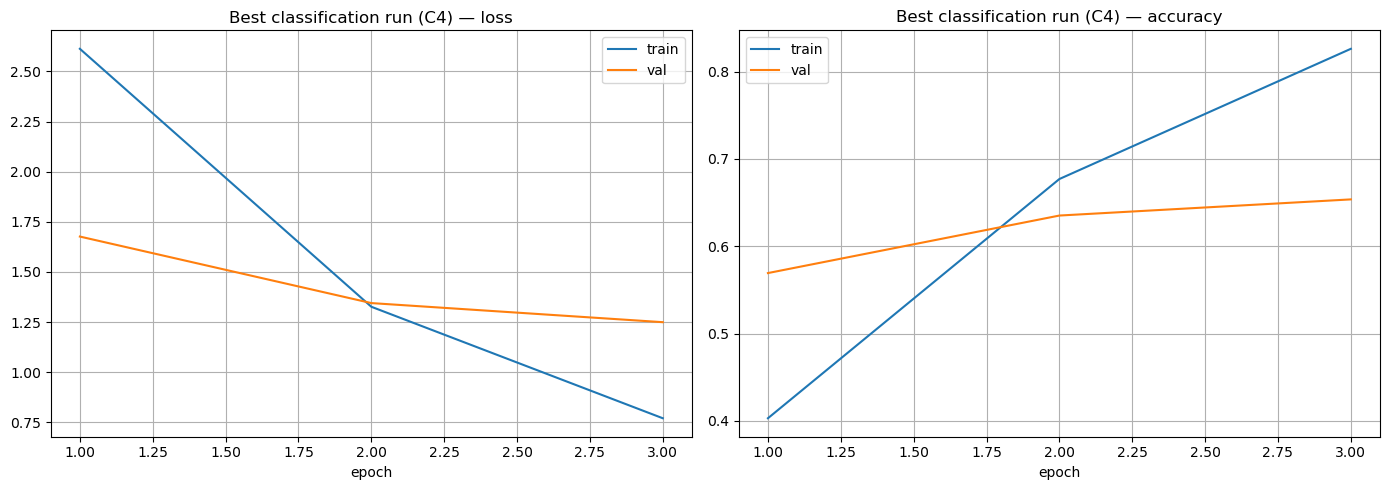

Saved: homeworks\HW10-11\artifacts\figures\classification_curves_best.png


In [12]:
torch.save(best_state, ART_DIR / 'best_classifier.pt')
with open(ART_DIR / 'best_classifier_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)
plot_history(best_history, f'Best classification run ({best_experiment_id})', FIG_DIR / 'classification_curves_best.png')

In [13]:
runs_df = pd.DataFrame(results)
runs_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes,best_epoch
0,C1,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,5,0.2600,NaN,None,None,None,simple CNN without augmentations,5
1,C2,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,5,0.2489,NaN,None,None,None,same CNN with augmentations,5
2,C3,classification,CIFAR100,42,ResNet,Adam,0.0010,3,0.5083,NaN,None,None,None,"ResNet18 pretrained, frozen backbone, train he...",3
3,C4,classification,CIFAR100,42,ResNet,Adam,0.0001,3,0.6537,0.6531,None,None,None,"ResNet18 pretrained, layer4 + fc trainable | s...",3


## 3. Часть B — OxfordIIITPet segmentation


100%|███████████████████████████████████████████████████████████████| 791918971/791918971 [07:12<00:00, 1829544.78it/s]


Extracting data\oxford-iiit-pet\images.tar.gz to data\oxford-iiit-pet


100%|█████████████████████████████████████████████████████████████████| 19173078/19173078 [00:07<00:00, 2599929.51it/s]


Extracting data\oxford-iiit-pet\annotations.tar.gz to data\oxford-iiit-pet
Dataset size: 3669
Image size: (300, 225)
Mask unique values: [1 2 3]


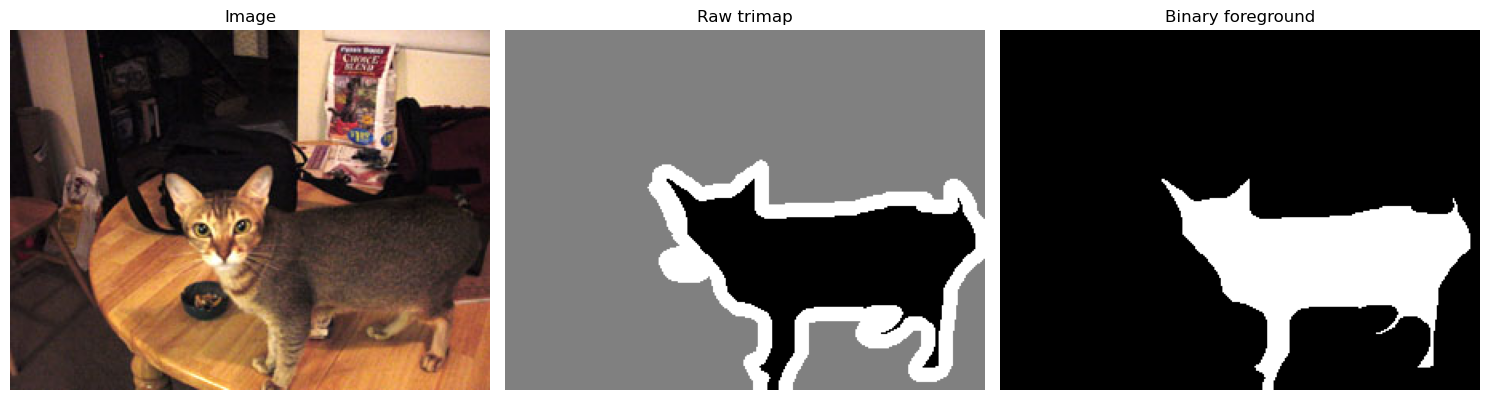

In [18]:
PET_ROOT = './data'
pet_weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
pet_preprocess = pet_weights.transforms()
seg_model = deeplabv3_mobilenet_v3_large(weights=pet_weights).to(device)
seg_model.eval()

pet_ds = OxfordIIITPet(root=PET_ROOT, split='test', target_types='segmentation', download=True)
MAX_PET_IMAGES = 8

print('Dataset size:', len(pet_ds))
img_pil, mask_pil = pet_ds[0]
mask_np = np.array(mask_pil)
print('Image size:', img_pil.size)
print('Mask unique values:', np.unique(mask_np))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_pil)
axes[0].set_title('Image')
axes[0].axis('off')
axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title('Raw trimap')
axes[1].axis('off')
axes[2].imshow(mask_np == 1, cmap='gray')
axes[2].set_title('Binary foreground')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [20]:
PET_FG_CLASSES = {8, 12}  # Кошка и собака

In [21]:
def trimap_to_binary(mask_pil):
    mask_np = np.array(mask_pil)
    return mask_np == 1

@torch.no_grad()
def run_segmentation_eval(model, dataset, score_threshold=0.3, max_images=8, visualize_n=3):
    model.eval()
    all_tp, all_fp, all_fn, all_tn = 0, 0, 0, 0
    all_ious = []
    vis_samples = []

    for idx in tqdm(range(min(max_images, len(dataset))), desc=f'seg eval @ thr={score_threshold}'):
        img_pil, mask_pil = dataset[idx]
        gt_binary = trimap_to_binary(mask_pil)
        input_tensor = pet_preprocess(img_pil).to(device)
        outputs = model(input_tensor.unsqueeze(0))
        logits = outputs['out'][0]
        logits = F.interpolate(
            logits.unsqueeze(0),
            size=gt_binary.shape,
            mode='bilinear',
            align_corners=False,
        )[0]
        probs = torch.softmax(logits, dim=0)
        pet_prob = probs[list(PET_FG_CLASSES)].max(dim=0).values
        pred_binary = (pet_prob >= score_threshold).cpu().numpy()

        gt_flat = gt_binary.astype(bool)
        tp = int(np.logical_and(pred_binary, gt_flat).sum())
        fp = int(np.logical_and(pred_binary, ~gt_flat).sum())
        fn = int(np.logical_and(~pred_binary, gt_flat).sum())
        tn = int(np.logical_and(~pred_binary, ~gt_flat).sum())

        all_tp += tp
        all_fp += fp
        all_fn += fn
        all_tn += tn

        denom = tp + fp + fn
        if denom > 0:
            all_ious.append(tp / denom)

        if len(vis_samples) < visualize_n:
            vis_samples.append((img_pil, gt_binary, pred_binary))

    pixel_accuracy = (all_tp + all_tn) / max(all_tp + all_fp + all_fn + all_tn, 1)
    mean_iou = float(np.mean(all_ious)) if len(all_ious) > 0 else 0.0
    metrics = {
        'pixel_accuracy': pixel_accuracy,
        'mean_iou': mean_iou,
        'tp': all_tp,
        'fp': all_fp,
        'fn': all_fn,
    }
    return metrics, vis_samples

def draw_segmentation_examples(vis_samples, title, save_path):
    fig, axes = plt.subplots(len(vis_samples), 3, figsize=(15, 5 * len(vis_samples)))
    if len(vis_samples) == 1:
        axes = np.array([axes])

    for row, (img_pil, gt_binary, pred_binary) in enumerate(vis_samples):
        axes[row, 0].imshow(img_pil)
        axes[row, 0].set_title('Image')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(gt_binary, cmap='gray')
        axes[row, 1].set_title('Ground truth')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred_binary, cmap='gray')
        axes[row, 2].set_title('Prediction')
        axes[row, 2].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)

seg eval @ thr=0.3:   0%|          | 0/8 [00:00<?, ?it/s]

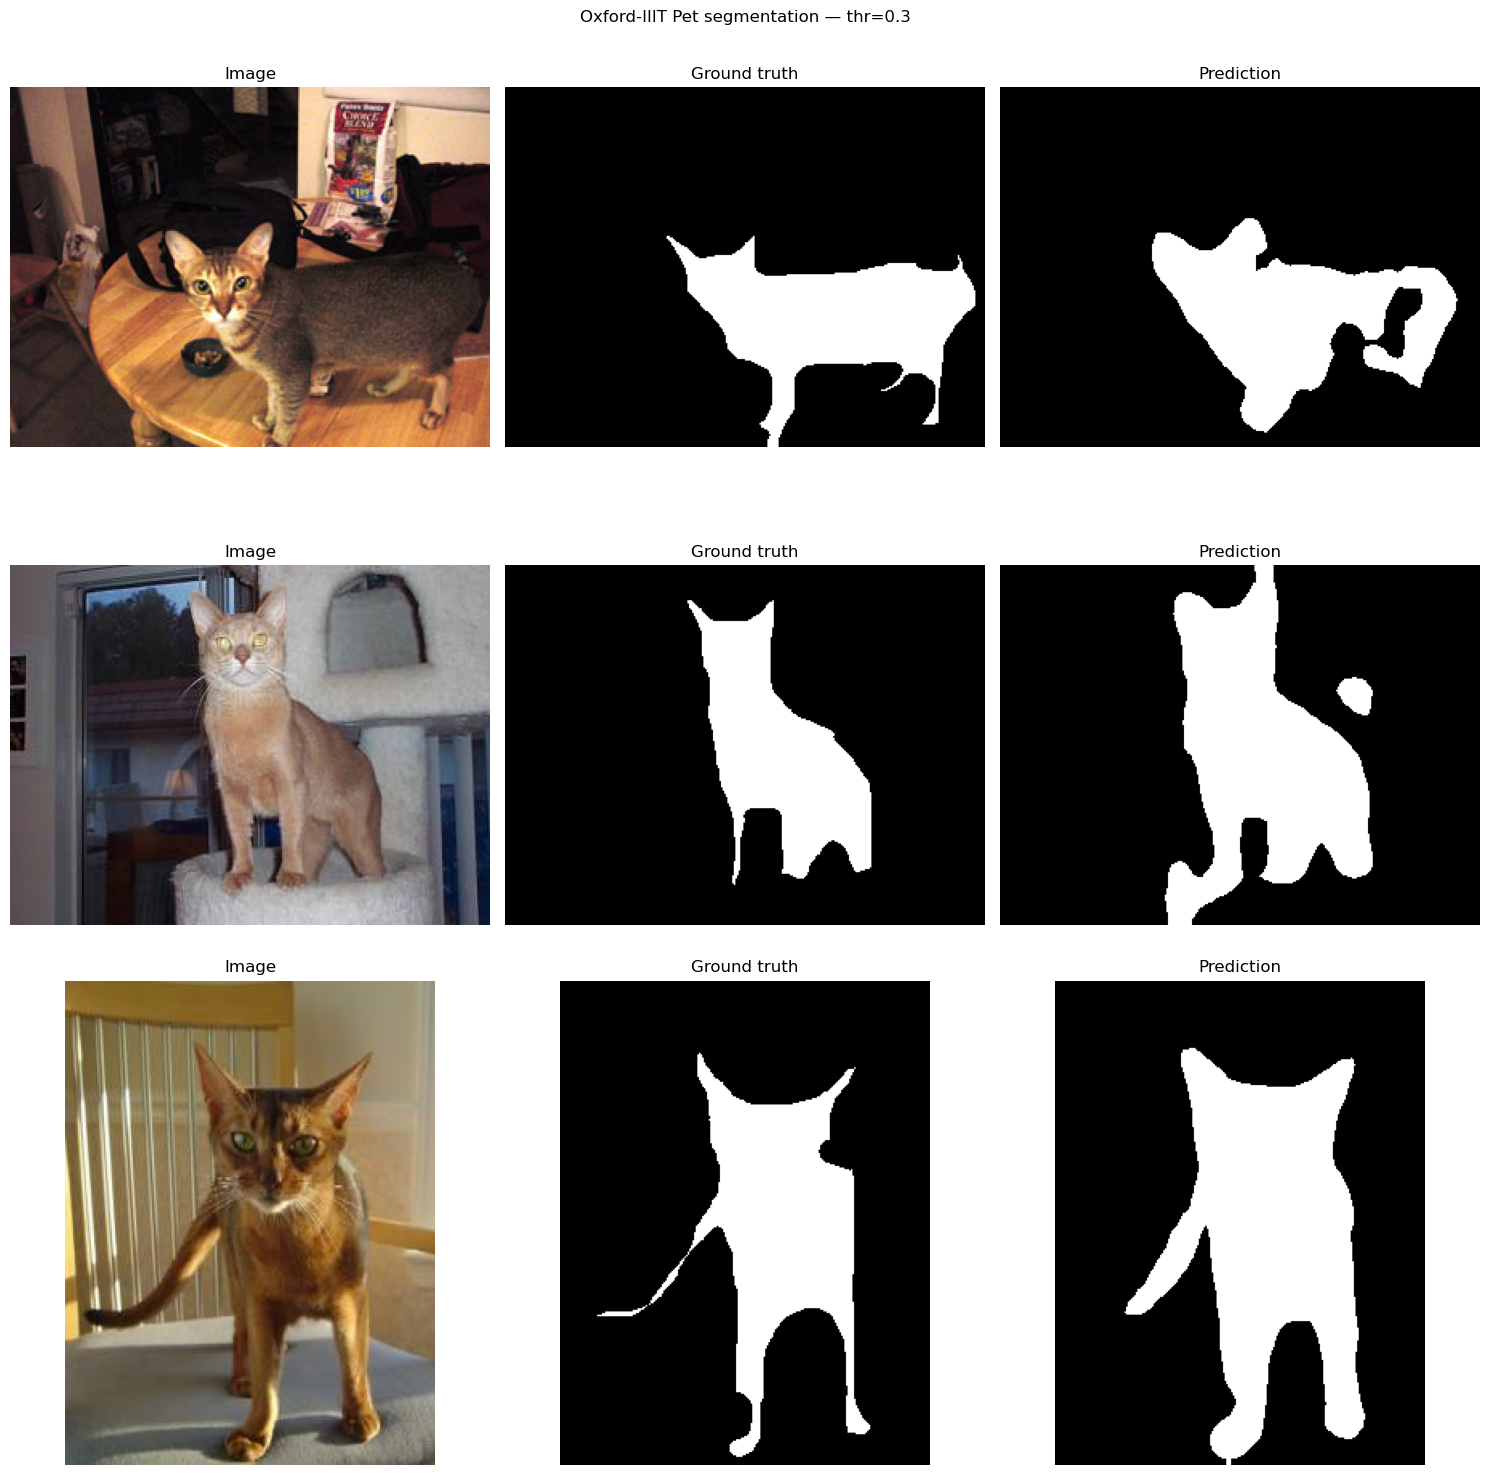

Saved: homeworks\HW10-11\artifacts\figures\pet_segmentation_thr03.png


seg eval @ thr=0.6:   0%|          | 0/8 [00:00<?, ?it/s]

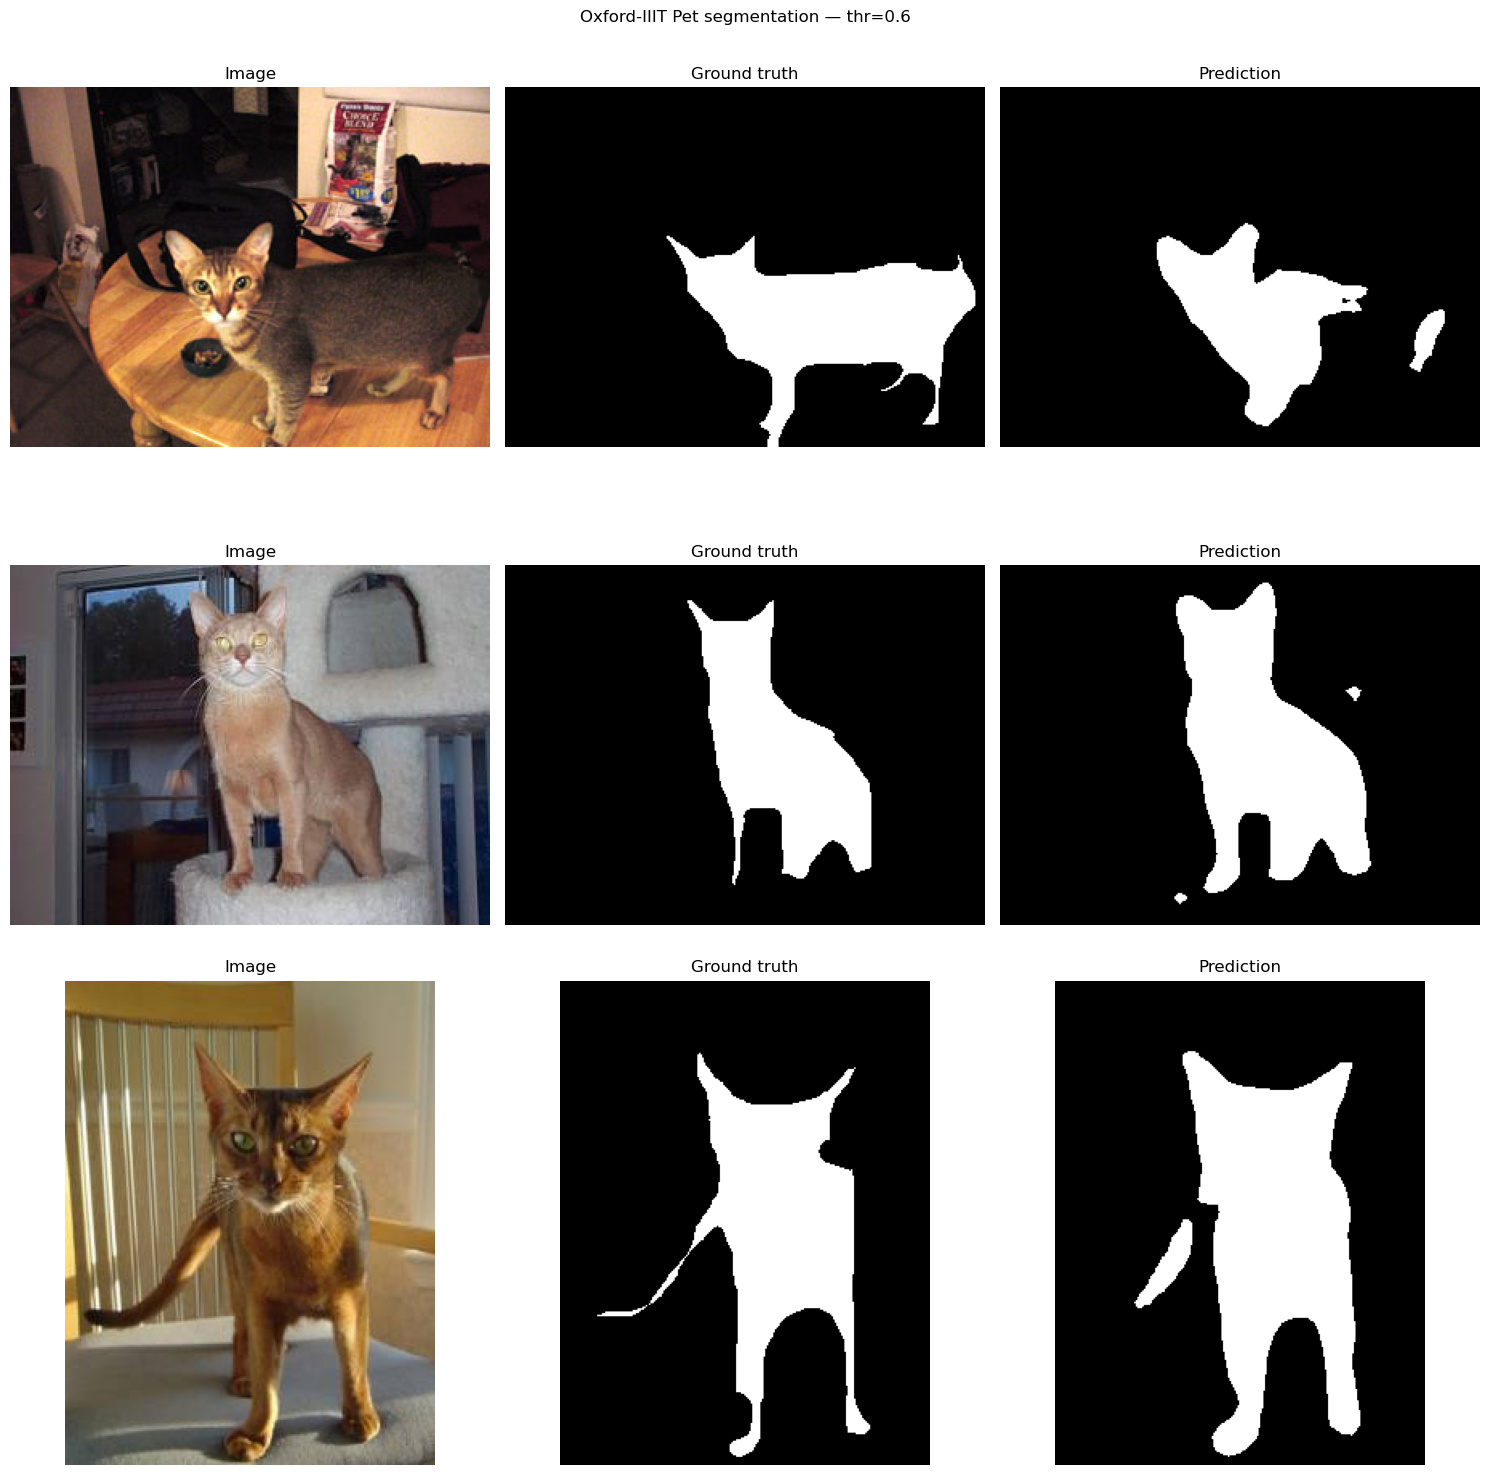

Saved: homeworks\HW10-11\artifacts\figures\pet_segmentation_thr06.png


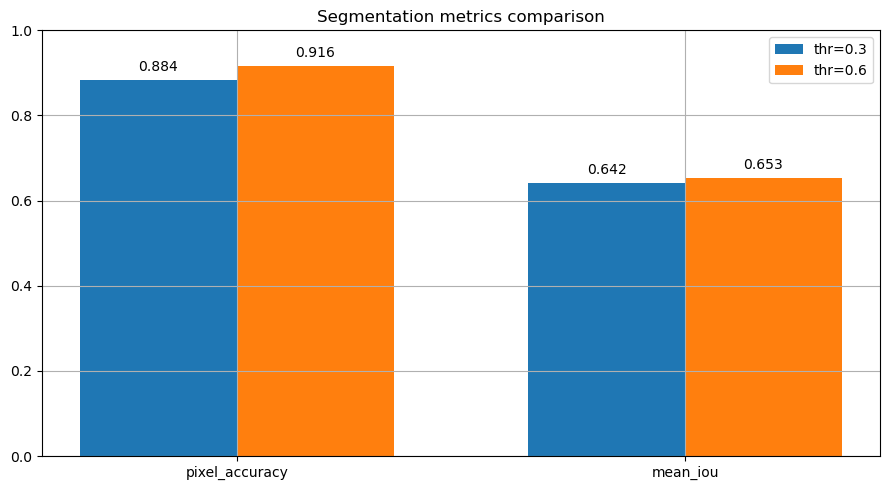

Saved: homeworks\HW10-11\artifacts\figures\pet_segmentation_metrics.png


C:\Users\frase\AppData\Local\Temp\ipykernel_24316\3959509441.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_runs = pd.concat([runs_df, seg_df], ignore_index=True)


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes,best_epoch
0,C1,classification,CIFAR100,42,SimpleCNN,Adam,0.001,5,0.26,NaN,None,None,NaN,simple CNN without augmentations,5.0
1,C2,classification,CIFAR100,42,SimpleCNN,Adam,0.001,5,0.2489,NaN,None,None,NaN,same CNN with augmentations,5.0
2,C3,classification,CIFAR100,42,ResNet,Adam,0.001,3,0.5083,NaN,None,None,NaN,"ResNet18 pretrained, frozen backbone, train he...",3.0
3,C4,classification,CIFAR100,42,ResNet,Adam,0.0001,3,0.6537,0.6531,None,None,NaN,"ResNet18 pretrained, layer4 + fc trainable | s...",3.0
4,S1,segmentation,Oxford-IIIT Pet test,42,DeepLabV3_MobileNet_V3_Large,,,0,,,,,0.641529,score_threshold=0.3,NaN
5,S2,segmentation,Oxford-IIIT Pet test,42,DeepLabV3_MobileNet_V3_Large,,,0,,,,,0.653256,score_threshold=0.6,NaN


In [24]:
metrics_p1, vis_p1 = run_segmentation_eval(seg_model, pet_ds, score_threshold=0.3, max_images=MAX_PET_IMAGES, visualize_n=3)
draw_segmentation_examples(vis_p1, 'Oxford-IIIT Pet segmentation — thr=0.3', FIG_DIR / 'pet_segmentation_thr03.png')
metrics_p2, vis_p2 = run_segmentation_eval(seg_model, pet_ds, score_threshold=0.6, max_images=MAX_PET_IMAGES, visualize_n=3)
draw_segmentation_examples(vis_p2, 'Oxford-IIIT Pet segmentation — thr=0.6', FIG_DIR / 'pet_segmentation_thr06.png')

seg_metrics = [
    {'experiment_id': 'S1', 'task': 'segmentation', 'dataset': 'Oxford-IIIT Pet test', 'seed': SEED,
     'model_summary': 'DeepLabV3_MobileNet_V3_Large', 'optimizer': '', 'lr': '', 'epochs_trained': 0,
     'best_val_accuracy': '', 'test_accuracy': '', 'precision': '', 'recall': '',
     'mean_iou': metrics_p1['mean_iou'], 'notes': 'score_threshold=0.3'},
    {'experiment_id': 'S2', 'task': 'segmentation', 'dataset': 'Oxford-IIIT Pet test', 'seed': SEED,
     'model_summary': 'DeepLabV3_MobileNet_V3_Large', 'optimizer': '', 'lr': '', 'epochs_trained': 0,
     'best_val_accuracy': '', 'test_accuracy': '', 'precision': '', 'recall': '',
     'mean_iou': metrics_p2['mean_iou'], 'notes': 'score_threshold=0.6'},
]
seg_df = pd.DataFrame(seg_metrics)

labels = ['pixel_accuracy', 'mean_iou']
x = np.arange(len(labels))
width = 0.35
v1_vals = [metrics_p1['pixel_accuracy'], metrics_p1['mean_iou']]
v2_vals = [metrics_p2['pixel_accuracy'], metrics_p2['mean_iou']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, v1_vals, width, label='thr=0.3')
ax.bar(x + width / 2, v2_vals, width, label='thr=0.6')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title('Segmentation metrics comparison')
ax.legend()
for i, val in enumerate(v1_vals):
    ax.text(i - width / 2, val + 0.02, f'{val:.3f}', ha='center')
for i, val in enumerate(v2_vals):
    ax.text(i + width / 2, val + 0.02, f'{val:.3f}', ha='center')
metrics_path = FIG_DIR / 'pet_segmentation_metrics.png'
plt.tight_layout()
plt.savefig(metrics_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', metrics_path)

all_runs = pd.concat([runs_df, seg_df], ignore_index=True)
all_runs.to_csv(ART_DIR / 'runs.csv', index=False)
all_runs
